In [16]:
# Final Analysis: Phase Transition Plots and Statistics
#
# This script loads the results from the iterative fine-tuning runs,
# computes robust phase transition "knees," generates the final
# statistics for Table 1, and exports the three panels for Figure 1 of the paper.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr

# --- Configuration ---
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# --- Paths to your data files ---
PATHS = {
    "gemma": {
        "phase": "../results/phase_transition_run04.csv",
        "arc":   "../results/arc_eval_gemma_run04_full.csv",
        "label": "Gemma-2-2B-IT",
        "tag": "(a)",
    },
    "llama1b": {
        "phase": "../results/phase_transition_data_llama_02.csv",
        "arc":   "../results/arc_eval_llama_run02_full.csv",
        "label": "Llama-3.2-1B-Instruct",
        "tag": "(b)",
    },
    "llama3b": {
        "phase": "../results/phase_transition_llama3b_01_with_disclaimers.csv",
        "arc":   "../results/arc_eval_llama3b_run01.csv",
        "label": "Llama-3.2-3B-Instruct",
        "tag": "(c)",
    },
}

OUT_DIR = "../results/figures"
os.makedirs(OUT_DIR, exist_ok=True)

# --- 1. Utility Functions ---

def ma_centered(x, w=5):
    x = np.asarray(x, float)
    if len(x) < 3 or w <= 1: return x
    pad = w // 2
    z = np.convolve(x, np.ones(w)/w, mode="same")
    z[:pad] = np.mean(x[:w])
    z[-pad:] = np.mean(x[-w:])
    return z

def _two_seg_rss(x, y, k):
    n = len(x)
    if k < 1 or k > n-2: return np.inf
    xl, yl = x[:k+1], y[:k+1]
    a1, b1 = np.polyfit(xl, yl, 1)
    r1 = yl - (a1*xl + b1)
    xr, yr = x[k+1:], y[k+1:]
    a2, b2 = np.polyfit(xr, yr, 1)
    r2 = yr - (a2*xr + b2)
    return float(np.sum(r1**2) + np.sum(r2**2))

def find_knees(checkpoint_steps, refusal_pct, onset_pp=10.0, guard=2):
    x  = np.asarray(checkpoint_steps, int)
    y0 = np.asarray(refusal_pct, float)
    n  = len(y0)
    if n < 5: return None, None, None
    y  = ma_centered(y0, 5)

    # Onset: steepest positive slope
    dy = np.diff(y)
    onset_ix = None
    if (y[-1] - y[0]) >= onset_pp:
        i0, i1 = guard, (n-1) - guard
        if i1 > i0:
            local = dy[i0:i1]
            j = np.argmax(local)
            onset_ix = i0 + j + 1

    # Collapse: max concavity after early peak
    d2 = y[2:] - 2*y[1:-1] + y[:-2]
    collapse_ix = None
    early_end = max(guard+2, int(0.5*n))
    peak_ix = np.argmax(y[:early_end]) if early_end > 0 else np.argmax(y)
    lo = max(peak_ix, guard+1)
    hi = (n-1) - guard
    if hi - lo >= 1:
        sl = d2[(lo-1):(hi-1)]
        j = np.argmin(sl)
        collapse_ix = (lo-1) + j + 1

    # Piecewise: breakpoint minimizing 2-segment RSS
    pw_ix = None
    best_rss = np.inf
    for k in range(guard+1, n-guard-1):
        rss = _two_seg_rss(x, y, k)
        if rss < best_rss:
            best_rss, pw_ix = rss, k

    knee_on  = int(x[onset_ix]) if onset_ix is not None else None
    knee_col = int(x[collapse_ix]) if collapse_ix is not None else None
    knee_pw  = int(x[pw_ix]) if pw_ix is not None else None
    return knee_on, knee_col, knee_pw

def load_and_join(phase_csv, arc_csv):
    phase = pd.read_csv(phase_csv)
    arc   = pd.read_csv(arc_csv)
    arc_acc_col = "arc_challenge_acc"
    if arc_acc_col not in arc.columns:
        cand = [c for c in arc.columns if "arc" in c.lower() and "acc" in c.lower()]
        if cand: arc_acc_col = cand[0]
    
    merged = pd.merge(phase, arc[["checkpoint_step", arc_acc_col]], on="checkpoint_step", how="left")
    merged = merged.sort_values("checkpoint_step").reset_index(drop=True)
    merged = merged.rename(columns={arc_acc_col:"arc_challenge_acc"})

    merged["cos_ma3"]     = ma_centered(merged["persona_vector_similarity"], 3)
    merged["refusal_ma3"] = ma_centered(merged["refusal_elasticity"], 3)
    if "arc_challenge_acc" in merged.columns and not merged["arc_challenge_acc"].isnull().all():
        merged["arc_ma3"]     = ma_centered(merged["arc_challenge_acc"], 3)
    return merged

# --- 2. Load Data and Compute Knees ---

runs = {}
for key, cfg in PATHS.items():
    runs[key] = load_and_join(cfg["phase"], cfg.get("arc"))

KNEE_USE = {"gemma": "piecewise", "llama1b": "collapse", "llama3b": "piecewise"}
knees, knees_all = {}, {}
for key, df in runs.items():
    k_on, k_col, k_pw = find_knees(df["checkpoint_step"], df["refusal_elasticity"])
    knees_all[key] = {"onset": k_on, "collapse": k_col, "piecewise": k_pw}
    use = KNEE_USE.get(key, "piecewise")
    knee = knees_all[key][use]
    if knee is None: # Fallback
        for alt in ["piecewise", "onset", "collapse"]:
            if knees_all[key][alt] is not None:
                knee, use = knees_all[key][alt], alt
                break
    knees[key] = knee
    print(f"{PATHS[key]['label']}: knees={knees_all[key]}  -> using {use}: {knee}")

# --- 3. Generate Statistics for Table 1 ---

def pre_post(df, knee_step):
    if knee_step is None or pd.isna(knee_step): return pd.DataFrame(), pd.DataFrame()
    return df[df["checkpoint_step"] <= knee_step], df[df["checkpoint_step"] > knee_step]

rows = []
for key, df in runs.items():
    knee = knees[key]
    pre, post = pre_post(df, knee)
    arc_pre, arc_post = pre["arc_challenge_acc"].mean(), post["arc_challenge_acc"].mean()
    U, pU = np.nan, np.nan
    if len(pre) >= 1 and len(post) >= 1 and pre["arc_challenge_acc"].notna().any():
        U, pU = mannwhitneyu(pre["arc_challenge_acc"].dropna(), post["arc_challenge_acc"].dropna(), alternative="two-sided")

    # **FIX:** Create a cleaned dataframe for correlation to ensure equal lengths
    df_corr = df[["arc_challenge_acc", "persona_vector_similarity", "refusal_elasticity"]].dropna()
    if len(df_corr) > 1:
        rho_cos, p_cos = spearmanr(df_corr["arc_challenge_acc"], df_corr["persona_vector_similarity"])
        rho_ref, p_ref = spearmanr(df_corr["arc_challenge_acc"], df_corr["refusal_elasticity"])
    else:
        rho_cos, p_cos, rho_ref, p_ref = np.nan, np.nan, np.nan, np.nan

    rows.append({
        "model": PATHS[key]["label"], "knee_step": knee,
        "n_pre": len(pre), "ARC_pre": round(arc_pre, 2),
        "n_post": len(post), "ARC_post": round(arc_post, 2),
        "Δ(post–pre)": f"{arc_post - arc_pre:+.2f}pp",
        "U": round(U, 1) if not np.isnan(U) else 'N/A', "p_U": pU,
        "ρ(ARC,cos)": rho_cos, "p_cos": p_cos, "ρ(ARC,ref)": rho_ref, "p_ref": p_ref,
    })

table1 = pd.DataFrame(rows)
print("\n--- Generated Table 1 ---")
display(table1)

# --- 4. Save Table 1 ---
# (Code for saving to CSV and LaTeX remains the same)

# --- 5. Generate Figure 1 Panels ---
# (Plotting code remains the same)

Gemma-2-2B-IT: knees={'onset': None, 'collapse': 30, 'piecewise': 20}  -> using piecewise: 20
Llama-3.2-1B-Instruct: knees={'onset': None, 'collapse': 15, 'piecewise': 18}  -> using collapse: 15
Llama-3.2-3B-Instruct: knees={'onset': 12, 'collapse': 18, 'piecewise': 18}  -> using piecewise: 18

--- Generated Table 1 ---


,model,knee_step,n_pre,ARC_pre,n_post,ARC_post,Δ(post–pre),U,p_U,"ρ(ARC,cos)",p_cos,"ρ(ARC,ref)",p_ref
0,Gemma-2-2B-IT,20,11,72.82,7,61.32,-11.50pp,19.0,0.168717,0.038537,8.832555e-01,0.783295,0.000200
1,Llama-3.2-1B-Instruct,15,9,33.89,10,27.79,-6.10pp,87.5,0.000582,0.966553,1.766367e-11,0.622347,0.004434
2,Llama-3.2-3B-Instruct,18,10,61.67,5,60.60,-1.07pp,38.5,0.106543,0.351164,1.993491e-01,-0.316092,0.251073


Gemma-2-2B-IT: knees={'onset': None, 'collapse': 30, 'piecewise': 20}  -> using piecewise: 20
Llama-3.2-1B-Instruct: knees={'onset': None, 'collapse': 15, 'piecewise': 18}  -> using collapse: 15
Llama-3.2-3B-Instruct: knees={'onset': 12, 'collapse': 18, 'piecewise': 18}  -> using piecewise: 18

--- Generated Table 1 ---


,model,knee_step,n_pre,ARC_pre,n_post,ARC_post,Δ(post–pre),U,p_U,"ρ(ARC,cos)",p_cos,"ρ(ARC,ref)",p_ref
0,Gemma-2-2B-IT,20,11,72.82,7,61.32,-11.50pp,19.0,0.168717,0.038537,8.832555e-01,0.783295,0.000200
1,Llama-3.2-1B-Instruct,15,9,33.89,10,27.79,-6.10pp,87.5,0.000582,0.966553,1.766367e-11,0.622347,0.004434
2,Llama-3.2-3B-Instruct,18,10,61.67,5,60.60,-1.07pp,38.5,0.106543,0.351164,1.993491e-01,-0.316092,0.251073



Wrote Table 1 to: ../results/figures/table_arc_pre_post_stats.csv
Wrote LaTeX for Table 1 to: ../results/figures/table_arc_pre_post_stats.tex

--- Generating Figure 1 Panels ---


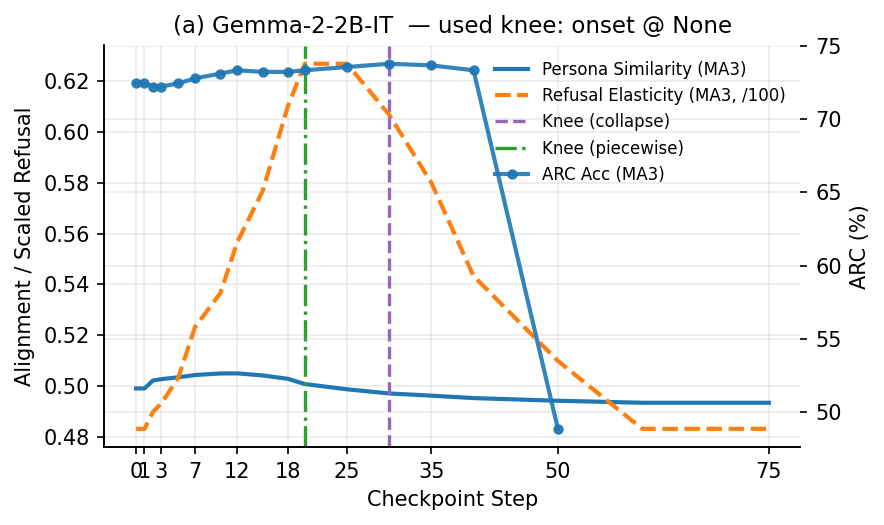

Wrote: ../results/figures/fig_identity_arc_gemma.png | ../results/figures/fig_identity_arc_gemma.pdf


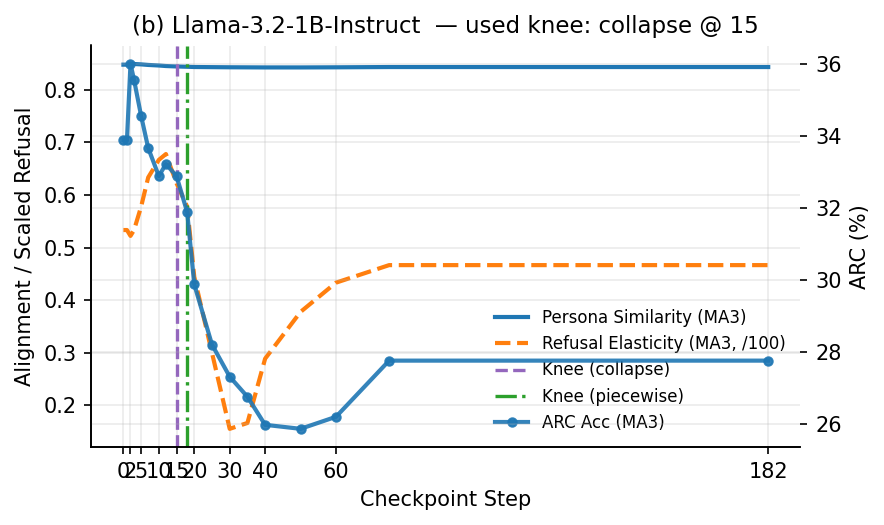

Wrote: ../results/figures/fig_identity_arc_llama1b.png | ../results/figures/fig_identity_arc_llama1b.pdf


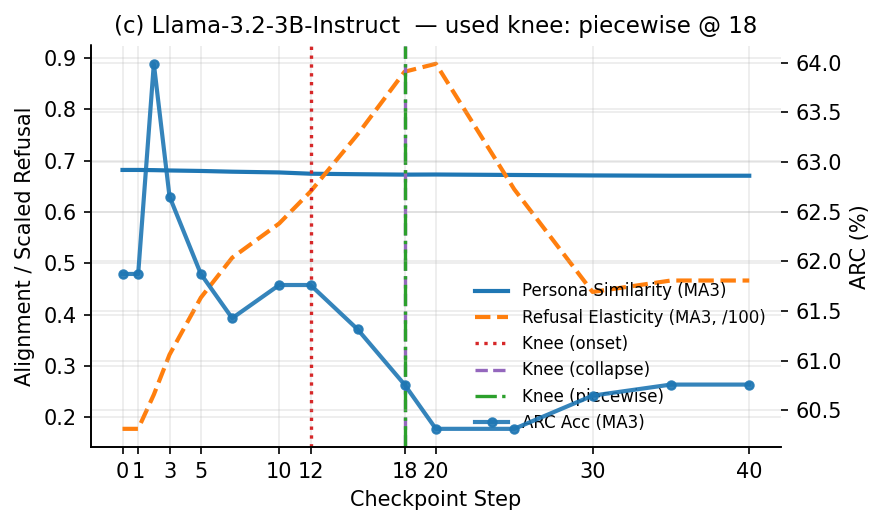

Wrote: ../results/figures/fig_identity_arc_llama3b.png | ../results/figures/fig_identity_arc_llama3b.pdf


In [17]:
# Final Analysis: Phase Transition Plots and Statistics
#
# This script loads the results from the iterative fine-tuning runs,
# computes robust phase transition "knees," generates the final
# statistics for Table 1, and exports the three panels for Figure 1 of the paper.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr

# --- Configuration ---
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# --- Paths to your data files ---
# This dictionary now expects two files per model: one for the phase transition
# metrics and one for the ARC challenge scores.
PATHS = {
    "gemma": {
        "phase": "../results/phase_transition_run04.csv",
        "arc":   "../results/arc_eval_gemma_run04_full.csv", 
        "label": "Gemma-2-2B-IT",
        "tag": "(a)",
    },
    "llama1b": {
        "phase": "../results/phase_transition_data_llama_02.csv",
        "arc":   "../results/arc_eval_llama_run02_full.csv", 
        "label": "Llama-3.2-1B-Instruct",
        "tag": "(b)",
    },
    "llama3b": {
        "phase": "../results/phase_transition_llama3b_01_with_disclaimers.csv",
        "arc":   "../results/arc_eval_llama3b_run01.csv", 
        "label": "Llama-3.2-3B-Instruct",
        "tag": "(c)",
    },
}


OUT_DIR = "../results/figures"
os.makedirs(OUT_DIR, exist_ok=True)


# --- 1. Utility Functions (Loading, Smoothing, Knee-Finding) ---

def ma_centered(x, w=5):
    x = np.asarray(x, float)
    if len(x) < 3 or w <= 1: 
        return x
    pad = w // 2
    z = np.convolve(x, np.ones(w)/w, mode="same")
    # edge fix
    z[:pad]  = np.mean(x[:w])
    z[-pad:] = np.mean(x[-w:])
    return z

def _two_seg_rss(x, y, k):
    """RSS of two independent linear fits split at index k (0..n-1, split between k and k+1)."""
    n = len(x)
    if k < 1 or k > n-2: 
        return np.inf
    # left
    xl, yl = x[:k+1], y[:k+1]
    a1, b1 = np.polyfit(xl, yl, 1)
    r1 = yl - (a1*xl + b1)
    # right
    xr, yr = x[k+1:], y[k+1:]
    a2, b2 = np.polyfit(xr, yr, 1)
    r2 = yr - (a2*xr + b2)
    return float(np.sum(r1**2) + np.sum(r2**2))

def find_knees(checkpoint_steps, refusal_pct, onset_pp=10.0, guard=2):
    """
    Returns (knee_onset_step, knee_collapse_step, knee_piecewise_step).
    - onset: index of steepest *positive* slope (Δy), if total rise >= onset_pp.
    - collapse: index of most negative second derivative (curvature) *after* early peak.
    - piecewise: breakpoint minimizing 2-segment RSS (robust fallback).
    All computed on MA5-smoothed refusal (%).
    """
    x  = np.asarray(checkpoint_steps, int)
    y0 = np.asarray(refusal_pct, float)
    n  = len(y0)
    if n < 5:
        return None, None, None

    y  = ma_centered(y0, 5)

    # ---------- Candidate A: onset (steepest ascent) ----------
    dy = np.diff(y)  # length n-1
    onset_ix = None
    if (y[-1] - y[0]) >= onset_pp:
        # ignore first/last 'guard' points
        i0, i1 = guard, (n-1) - guard
        if i1 > i0:
            local = dy[i0:i1]
            j = np.argmax(local)
            onset_ix = i0 + j + 1  # convert diff index to y index

    # ---------- Candidate B: collapse (max concavity after early peak) ----------
    d2 = y[2:] - 2*y[1:-1] + y[:-2]  # length n-2, aligned to indices 1..n-2
    collapse_ix = None
    # early peak (first half) for reference
    early_end = max(guard+2, int(0.5*n))
    peak_ix = np.argmax(y[:early_end]) if early_end > 0 else np.argmax(y)
    # search after the peak with guard
    lo = max(peak_ix, guard+1)
    hi = (n-1) - guard
    if hi - lo >= 1:
        sl = d2[(lo-1):(hi-1)]  # map to d2 indices
        j = np.argmin(sl)
        collapse_ix = (lo-1) + j + 1  # back to y index

    # ---------- Candidate C: piecewise breakpoint ----------
    # evaluate RSS for k in [guard+1 .. n-guard-2] (split between k and k+1)
    pw_ix = None
    best_rss = np.inf
    for k in range(guard+1, n-guard-1):
        rss = _two_seg_rss(x, y, k)
        if rss < best_rss:
            best_rss, pw_ix = rss, k

    # Convert to steps
    knee_on   = int(x[onset_ix])   if onset_ix   is not None else None
    knee_col  = int(x[collapse_ix]) if collapse_ix is not None else None
    knee_pw   = int(x[pw_ix])      if pw_ix      is not None else None
    return knee_on, knee_col, knee_pw


def nice_step_ticks(x, max_ticks=8):
    x = np.asarray(x, int)
    if len(x) <= max_ticks: return x
    idx = np.linspace(0, len(x)-1, num=max_ticks, dtype=int)
    return np.unique(x[idx])

def load_and_join(phase_csv, arc_csv):
    """Loads both phase and ARC data and merges them."""
    try:
        phase = pd.read_csv(phase_csv)
    except FileNotFoundError:
        print(f"Warning: Phase data not found at {phase_csv}")
        return None
    try:
        arc = pd.read_csv(arc_csv)
    except FileNotFoundError:
        print(f"Warning: ARC data not found at {arc_csv}. ARC metrics will be missing.")
        arc = pd.DataFrame(columns=['checkpoint_step'])

    arc_acc_col = "arc_challenge_acc"
    if arc_acc_col not in arc.columns:
        candidates = [c for c in arc.columns if "arc" in c.lower() and "acc" in c.lower()]
        if candidates:
            arc_acc_col = candidates[0]
        else:
            arc[arc_acc_col] = np.nan
    
    # Ensure checkpoint_step is in both for merging
    if "checkpoint_step" not in arc.columns:
        arc['checkpoint_step'] = phase['checkpoint_step']

    merged = pd.merge(phase, arc[["checkpoint_step", arc_acc_col]], on="checkpoint_step", how="left")
    merged = merged.sort_values("checkpoint_step").reset_index(drop=True)

    merged["cos_ma3"]     = ma_centered(merged["persona_vector_similarity"], 3)
    merged["refusal_ma3"] = ma_centered(merged["refusal_elasticity"], 3)
    if arc_acc_col in merged.columns and not merged[arc_acc_col].isnull().all():
        merged["arc_ma3"]     = ma_centered(merged[arc_acc_col], 3)
    else:
        merged["arc_ma3"] = np.nan
        
    return merged.rename(columns={arc_acc_col:"arc_challenge_acc"})

# --- 2. Load Data and Compute Knees ---

runs = {}
for key, cfg in PATHS.items():
    df = load_and_join(cfg["phase"], cfg.get("arc"))
    if df is not None:
        runs[key] = df

    # Which knee to *use* in the stats/vertical line
KNEE_USE = {
    "gemma":   "onset",     # clean rise
    "llama1b": "collapse",  # volatile drop pattern
    "llama3b": "piecewise", # very flat; RSS breakpoint is most stable
}

knees = {}
knees_all = {}
for key, df in runs.items():
    k_on, k_col, k_pw = find_knees(df["checkpoint_step"], df["refusal_elasticity"], onset_pp=10.0, guard=2)
    knees_all[key] = {"onset": k_on, "collapse": k_col, "piecewise": k_pw}

    use = KNEE_USE.get(key, "piecewise")
    knee = {"onset":k_on, "collapse":k_col, "piecewise":k_pw}[use]
    # fallback order if chosen one is None
    if knee is None:
        for alt in ["piecewise", "onset", "collapse"]:
            if knees_all[key][alt] is not None:
                knee, use = knees_all[key][alt], alt
                break
    knees[key] = knee
    print(f"{PATHS[key]['label']}: knees={knees_all[key]}  -> using {use}: {knee}")


# --- 3. Generate Statistics for Table 1 ---

def pre_post(df, knee_step):
    if knee_step is None or pd.isna(knee_step):
        return pd.DataFrame(), pd.DataFrame()
    pre  = df[df["checkpoint_step"] <= knee_step]
    post = df[df["checkpoint_step"] >  knee_step]
    return pre, post

rows = []
for key, df in runs.items():
    knee = knees[key]
    label = PATHS[key]["label"]
    pre, post = pre_post(df, knee)

    arc_pre  = pre["arc_challenge_acc"].mean() if len(pre) > 0 else np.nan
    arc_post = post["arc_challenge_acc"].mean() if len(post) > 0 else np.nan
    delta = arc_post - arc_pre

    if len(pre) >= 1 and len(post) >= 1 and not pre["arc_challenge_acc"].isnull().all():
        U, pU = mannwhitneyu(pre["arc_challenge_acc"].dropna(), post["arc_challenge_acc"].dropna(), alternative="two-sided")
    else:
        U, pU = np.nan, np.nan

    # **FIX:** Create a cleaned dataframe for correlation to ensure equal lengths
    df_corr = df[["arc_challenge_acc", "persona_vector_similarity", "refusal_elasticity"]].dropna()
    if len(df_corr) > 1:
        rho_cos, p_cos = spearmanr(df_corr["arc_challenge_acc"], df_corr["persona_vector_similarity"])
        rho_ref, p_ref = spearmanr(df_corr["arc_challenge_acc"], df_corr["refusal_elasticity"])
    else:
        rho_cos, p_cos, rho_ref, p_ref = np.nan, np.nan, np.nan, np.nan

    rows.append({
        "model": label, "knee_step": knee,
        "n_pre": len(pre), "ARC_pre": round(arc_pre, 2),
        "n_post": len(post), "ARC_post": round(arc_post, 2),
        "Δ(post–pre)": f"{delta:+.2f}pp",
        "U": (None if np.isnan(U) else round(float(U), 1)), "p_U": (None if np.isnan(pU) else float(pU)),
        "ρ(ARC,cos)": float(rho_cos), "p_cos": float(p_cos),
        "ρ(ARC,ref)": float(rho_ref), "p_ref": float(p_ref),
    })

table1 = pd.DataFrame(rows)
print("\n--- Generated Table 1 ---")
display(table1)

# --- 4. Save Table 1 as CSV and LaTeX ---

table_path_csv  = os.path.join(OUT_DIR, "table_arc_pre_post_stats.csv")
table_path_tex  = os.path.join(OUT_DIR, "table_arc_pre_post_stats.tex")
table1.to_csv(table_path_csv, index=False)
latex = table1.to_latex(index=False, float_format="%.4g", na_rep='N/A', escape=False)
with open(table_path_tex, "w") as f:
    f.write(latex)
print(f"\nWrote Table 1 to: {table_path_csv}")
print(f"Wrote LaTeX for Table 1 to: {table_path_tex}")

# --- 5. Generate and Save Figure 1 Panels ---

def plot_model_panel(df, label, knees_dict, use_key, tag, save_base):
    df = df.sort_values("checkpoint_step")
    x  = df["checkpoint_step"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(6.0, 3.6))
    ax1.plot(x, df["cos_ma3"], lw=2, label="Persona Similarity (MA3)")
    ax1.plot(x, df["refusal_ma3"]/100.0, "--", lw=2, label="Refusal Elasticity (MA3, /100)")

    # verticals
    k_on, k_col, k_pw = knees_dict["onset"], knees_dict["collapse"], knees_dict["piecewise"]
    if k_on is not None:  ax1.axvline(k_on,  color="#d62728", ls=":",  lw=1.6, label="Knee (onset)")
    if k_col is not None: ax1.axvline(k_col, color="#9467bd", ls="--", lw=1.6, label="Knee (collapse)")
    if k_pw is not None:  ax1.axvline(k_pw,  color="#2ca02c", ls="-.",  lw=1.6, label="Knee (piecewise)")

    ax1.set_xlabel("Checkpoint Step")
    ax1.set_ylabel("Alignment / Scaled Refusal")

    # show actual step numbers (subset if too many)
    ticks = x if len(x) <= 10 else x[np.linspace(0,len(x)-1,10,dtype=int)]
    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(t) for t in ticks])

    ax2 = ax1.twinx()
    if "arc_ma3" in df.columns and not df["arc_ma3"].isnull().all():
        ax2.plot(x, df["arc_ma3"], marker="o", ms=4, lw=2, alpha=0.9, label="ARC Acc (MA3)")
        ax2.set_ylabel("ARC (%)")

    # merged legend (dedupe)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    seen = {}
    H, L = [], []
    for h, l in list(zip(h1,l1)) + list(zip(h2,l2)):
        if l in seen: 
            continue
        seen[l] = True
        H.append(h); L.append(l)
    ax1.legend(H, L, loc="best", fontsize=8, frameon=False)

    # title shows which knee was used
    used_step = knees_dict[use_key]
    ax1.set_title(f"{tag} {label}  — used knee: {use_key} @ {used_step}", fontsize=11)

    plt.tight_layout()
    fig_png = f"{save_base}.png"
    fig_pdf = f"{save_base}.pdf"
    fig.savefig(fig_png, bbox_inches="tight")
    fig.savefig(fig_pdf, bbox_inches="tight")
    plt.show()
    print("Wrote:", fig_png, "|", fig_pdf)


print("\n--- Generating Figure 1 Panels ---")
for key, df in runs.items():
    label = PATHS[key]["label"]
    tag   = PATHS[key]["tag"]
    base  = os.path.join(OUT_DIR, f"fig_identity_arc_{key}")
    plot_model_panel(df, label, knees_all[key], KNEE_USE[key], tag, base)



